# Second regression example

[Second regression example | Regression | Probability and Statistics | Khan Academy | YouTube](https://www.youtube.com/watch?v=ww_yT9ckPWw)

![second-graph.png](./IMAGES/second-graph.png)

# Least Squares Regression Line: Worked Example (Step 2 – Computing the Slope)

## Goal

We want to find the **equation of the regression line** that best fits a given set of data points, where “best” means:

> The line **minimizes the sum of the squared distances** from the points to the line.

The regression line has the familiar form:

$$
y = mx + b
$$

In this notebook, we focus specifically on **Step 2: computing the slope $ m $** using the derived least-squares formula.

---

## Reminder: Least-Squares Slope Formula

The slope of the regression line that minimizes squared error is:

$$
m
=
\frac{
\overline{xy} - \overline{x}\,\overline{y}
}{
\overline{x^2} - (\overline{x})^2
}
$$

### Memory Aid
- **First terms**: take products first, then average  
  - $ \overline{xy} $, $ \overline{x^2} $
- **Second terms**: average first, then multiply  
  - $ \overline{x}\,\overline{y} $, $ (\overline{x})^2 $

---

## Given Data Points

We are working with four points:

$$
(-2, -3), \quad (-1, -1), \quad (1, 2), \quad (4, 3)
$$

---

## Step 1: Compute the Required Means

### Mean of $ x $

$$
\overline{x}
=
\frac{-2 + (-1) + 1 + 4}{4}
=
\frac{2}{4}
=
\frac{1}{2}
$$

---

### Mean of $ y $

$$
\overline{y}
=
\frac{-3 + (-1) + 2 + 3}{4}
=
\frac{1}{4}
$$

---

### Mean of $ xy $

$$
\overline{xy}
=
\frac{
(-2)(-3) + (-1)(-1) + (1)(2) + (4)(3)
}{4}
=
\frac{6 + 1 + 2 + 12}{4}
=
\frac{21}{4}
$$

---

### Mean of $ x^2 $

$$
\overline{x^2}
=
\frac{
(-2)^2 + (-1)^2 + 1^2 + 4^2
}{4}
=
\frac{4 + 1 + 1 + 16}{4}
=
\frac{22}{4}
=
\frac{11}{2}
$$

---

## Step 2: Compute the Slope $ m $

Substitute the computed means into the slope formula:

$$
m
=
\frac{
\frac{21}{4} - \left(\frac{1}{2}\right)\left(\frac{1}{4}\right)
}{
\frac{11}{2} - \left(\frac{1}{2}\right)^2
}
$$

---

### Simplification

Numerator:
$$
\frac{21}{4} - \frac{1}{8}
$$

Denominator:
$$
\frac{11}{2} - \frac{1}{4}
$$

To simplify, multiply **numerator and denominator by 8**:

$$
m
=
\frac{
42 - 1
}{
44 - 2
}
=
\frac{41}{42}
$$

---

## Interpretation of the Slope

- The slope is:
$$
\boxed{m = \frac{41}{42}}
$$
- This is slightly less than 1, meaning:
  - As $ x $ increases by 1, $ y $ increases by slightly less than 1 on average
- This aligns with the visual trend of the data points

---

## Next Step

With the slope now computed:

- The **y-intercept** can be found using:
$$
b = \overline{y} - m\,\overline{x}
$$
- After that, we will evaluate **how good the fit is** by computing:
  - **$ R^2 $** (coefficient of determination)

This will tell us how much of the variation in $ y $ is explained by the regression line.


# Least Squares Regression + $R^2$ (From Scratch)

In [2]:
import numpy as np
import matplotlib.pyplot as plt


### Step 1: Define the Data

In [3]:
# Given data points
x = np.array([-2, -1, 1, 4])
y = np.array([-3, -1, 2, 3])


### Step 2: Compute Required Means

In [4]:
x_mean = np.mean(x)
y_mean = np.mean(y)
xy_mean = np.mean(x * y)
x2_mean = np.mean(x ** 2)

x_mean, y_mean, xy_mean, x2_mean


(np.float64(0.5), np.float64(0.25), np.float64(5.25), np.float64(5.5))

### Step 3: Compute Regression Coefficients (Derived Formula)
Slope

$$
m = \frac{\overline{xy} - \overline{x} \cdot \overline{y}}{\overline{x^2} - (\overline{x})^2}
$$


In [5]:
m = (xy_mean - x_mean * y_mean) / (x2_mean - x_mean**2)


### Intercept

$$
b = \overline{y} - m \cdot \overline{x} 
$$


In [6]:
b = y_mean - m * x_mean

m, b


(np.float64(0.9761904761904762), np.float64(-0.23809523809523808))

### Regression Line Equation

In [7]:
print(f"Regression line: y = {m:.4f}x + {b:.4f}")

Regression line: y = 0.9762x + -0.2381


(Equivalent to $ y = \frac{41}{42}x - \frac{5}{21} $ )

### Step 4: Compute Predicted Values

In [8]:
y_pred = m * x + b


### Step 5: Compute $R^2$ (Coefficient of Determination)

$$
R^2 = 1 - \frac{\sum (y - \hat{y})^2}{\sum (y - \bar{y})^2}
$$


In [9]:
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - y_mean) ** 2)

r_squared = 1 - ss_res / ss_tot
r_squared


np.float64(0.879644165358451)

### Interpretation of $R^2$

In [10]:
print(f"R^2 = {r_squared:.4f}")

R^2 = 0.8796



* $R^2$ close to 1 → strong linear fit
* $R^2$ close to 0 → weak linear fit


### Step 6: Plot the Data and Regression Line

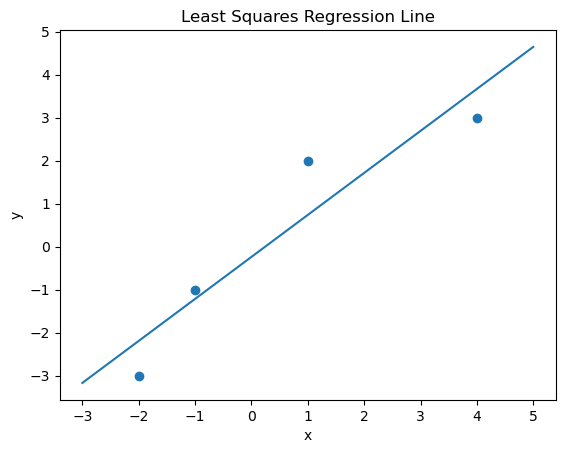

In [11]:
x_line = np.linspace(min(x) - 1, max(x) + 1, 200)
y_line = m * x_line + b

plt.figure()
plt.scatter(x, y)
plt.plot(x_line, y_line)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Least Squares Regression Line")
plt.show()


### Optional: Verify with NumPy

In [12]:
m_np, b_np = np.polyfit(x, y, 1)
m_np, b_np


(np.float64(0.976190476190476), np.float64(-0.23809523809523797))

### Summary
* Regression line:

$$
y = \frac{41}{42}x - \frac{5}{21}
$$


* $R^2$ quantifies how much of the variation in $y$ is explained by $x$
* This implementation:
    - Uses pure formulas
    - Matches NumPy’s built-in regression
    - Is scalable to larger datasets


# [Context](https://github.com/progressivepull/Statistics-Deep-Dives/blob/main/khan_academy/Content.md)